<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab5_CNN_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 5: CNN for Two-Class Image Classification

Practical 4 classified rows of numbers. This one classifies **images**, and the whole point is that images have a property plain numbers don't: **a pattern means the same thing wherever it appears**. A defect in the top-left corner of a fabric swatch is the same defect in the bottom-right. That property is what a convolutional layer is built around, and a Dense layer has no way to express it.

Rather than run Cats vs Dogs, I used a domain dataset, **automated fabric quality control**, deciding whether a woven swatch is clean or defective. It's a real two-class vision problem, it's the kind of thing an actual textile line needs, and critically it lets me *prove* what the convolution is buying rather than just asserting it.

**Pipeline:** image → conv filters slide over it looking for local patterns → pooling shrinks the map → more filters on the result → flatten → dense layer → sigmoid → clean or defective.

## What actually changes from Practical 4

| | Practical 4 (MLP) | Practical 5 (CNN) |
|---|---|---|
| Input | 3 numbers | 32x32 grid of pixels |
| First layer | `Dense` (every input to every neuron | `Conv2D`) a small filter slid across the image |
| Weights | one per input, per neuron | **one small filter reused at every position** |
| Downsizing | none | `MaxPooling2D` |
| Output | 4 neurons + softmax | 1 neuron + sigmoid (two classes) |

The output head goes *back* to Practical 3's binary setup (one sigmoid neuron, binary crossentropy) because this is a two-class problem. The genuinely new idea is entirely in the first layers.

### In layman terms: what a convolution filter actually is

A `Dense` layer gives every pixel its own private weight. Pixel (5,5) and pixel (20,20) are unrelated as far as it's concerned. It has no idea they're even next to anything. So if it learns "a dark blob at position (5,5) means defect", that knowledge is stored *at position (5,5)* and does nothing for a dark blob at (20,20). It would have to learn the same thing separately, from scratch, for all 1024 positions.

A convolution filter is a small grid of weights (here 3x3) that gets **slid across the whole image**, computing a weighted sum at every position. Crucially it's the *same nine numbers* everywhere. So:

- It can only see a small neighbourhood at a time, which is exactly right, because a defect *is* a local thing.
- Learning it once means it works everywhere. This is called **parameter sharing**, and it's why a CNN needs vastly fewer weights.
- The output is a **feature map**: a grid showing how strongly that pattern fired at each location.

This is the whole idea. A Dense layer asks "what's at this exact address?" A conv layer asks "is this pattern anywhere?"

**Pooling** then takes each small block of the feature map and keeps only the strongest response, halving the width and height. It throws away exact position while keeping "it was around here", which makes the network progressively less fussy about precise placement and cuts the computation.

## The use case: automated fabric defect detection

A camera photographs woven fabric moving down a production line. The model decides: **clean** or **defective**.

Every image is a freshly generated plain weave (crossing warp and weft threads) with its own random lighting, exposure and yarn fuzz, so no two images are alike. Defective samples get exactly one localised flaw, of one of four real types:

| Defect | What it looks like |
|---|---|
| Slub | a lump of thick yarn, short bright bar |
| Hole | missing yarn, small dark blob |
| Thread break | a snapped warp thread, short vertical strip with the weave gone |
| Misweave | threads out of sequence, small patch with the weave pattern shifted |

Two deliberate design decisions, for the same reason as Practical 4's climate rules. So the experiment can actually prove something:

1. **The defect can appear anywhere in the frame.** Fabric doesn't flaw politely in the centre. This is what makes position-independence necessary rather than optional.
2. **Defects don't change the overall brightness.** A slub brightens a few pixels, a hole darkens a few. Averaged over the image, a defective swatch looks the same as a clean one. This blocks the cheap solution (you can't just threshold the mean and win) so the model is forced to detect *local structure*.

3% of labels are flipped, standing in for an inspector mislabelling a borderline swatch.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

IMG = 32
DEFECT_TYPES = ["slub", "hole", "thread_break", "misweave"]

def weave(rng, size=IMG):
    """A plain woven fabric: crossing warp/weft threads, plus lighting and yarn noise."""
    y, x = np.mgrid[0:size, 0:size]
    period = 4
    warp = 0.5 + 0.5*np.cos(2*np.pi*x/period)
    weft = 0.5 + 0.5*np.cos(2*np.pi*y/period)
    img = 0.55 + 0.18*(warp*weft) + 0.10*(warp+weft)/2
    img += rng.normal(0, 0.035, (size, size))     # yarn fuzz
    img *= rng.uniform(0.88, 1.12)                # lighting
    img += rng.uniform(-0.05, 0.05)               # exposure
    return np.clip(img, 0, 1)

def add_defect(img, rng, region=None):
    """Insert exactly one localised defect. region limits WHERE it may land."""
    size = img.shape[0]
    kind = DEFECT_TYPES[rng.integers(len(DEFECT_TYPES))]
    m = 5
    if region is None:
        cx, cy = rng.integers(m, size-m), rng.integers(m, size-m)
    else:
        x0, x1, y0, y1 = region
        cx, cy = rng.integers(x0, x1), rng.integers(y0, y1)

    if kind == "slub":
        L, h = rng.integers(4, 8), rng.integers(1, 3)
        img[max(0,cy-h):cy+h, max(0,cx-L//2):cx+L//2] += rng.uniform(0.18, 0.30)
    elif kind == "hole":
        r = rng.integers(2, 4)
        yy, xx = np.mgrid[0:size, 0:size]
        img[((yy-cy)**2 + (xx-cx)**2) <= r*r] -= rng.uniform(0.22, 0.34)
    elif kind == "thread_break":
        L, w = rng.integers(6, 11), rng.integers(1, 3)
        y0 = max(0, cy-L//2)
        patch = img[y0:y0+L, max(0,cx-w):cx+w]
        if patch.size: img[y0:y0+L, max(0,cx-w):cx+w] = patch.mean()
    else:  # misweave
        s = rng.integers(5, 9)
        y0, x0 = max(0,cy-s//2), max(0,cx-s//2)
        patch = img[y0:y0+s, x0:x0+s]
        if patch.shape[0] > 2 and patch.shape[1] > 2:
            img[y0:y0+s, x0:x0+s] = np.roll(np.roll(patch, 2, axis=0), 2, axis=1)
    return np.clip(img, 0, 1), kind

def make_set(n, rng, defect_region=None, noise_frac=0.03):
    X = np.zeros((n, IMG, IMG), dtype=np.float32)
    y = np.zeros(n, dtype=int)
    kinds = np.array(["clean"]*n, dtype=object)
    for i in range(n):
        img = weave(rng)
        if i % 2 == 1:
            img, k = add_defect(img, rng, region=defect_region)
            y[i], kinds[i] = 1, k
        X[i] = img
    flipped = rng.choice(n, int(noise_frac*n), replace=False)
    y[flipped] = 1 - y[flipped]
    return X[..., None], y, kinds

rng = np.random.default_rng(42)
X_train, y_train, k_train = make_set(4000, rng)
X_test,  y_test,  k_test  = make_set(1000, rng)

print("train:", X_train.shape, " test:", X_test.shape)
print("train balance -> clean:", (y_train==0).sum(), " defective:", (y_train==1).sum())

I0000 00:00:1785752089.038589    4195 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785752089.990298    4195 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785752101.595055    4195 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


train: (4000, 32, 32, 1)  test: (1000, 32, 32, 1)
train balance -> clean: 1998  defective: 2002


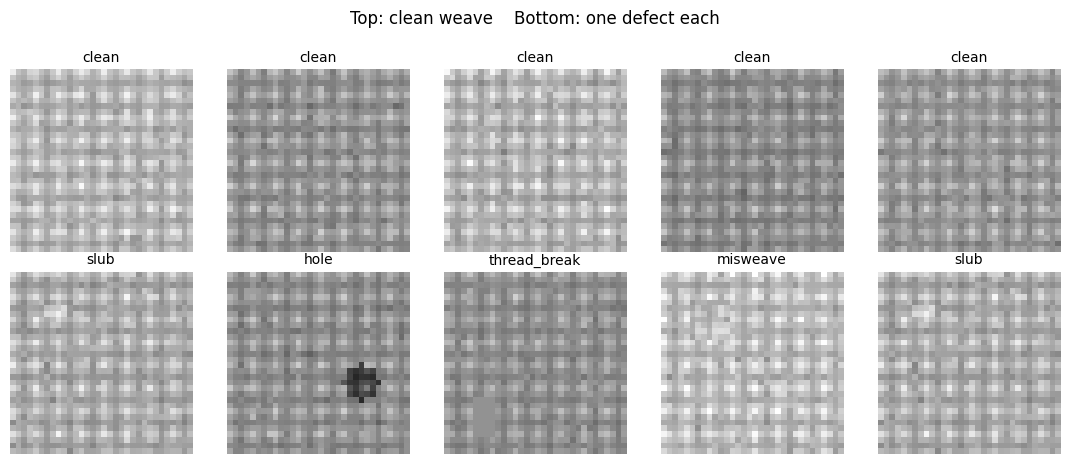

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
clean_idx = np.where(y_train == 0)[0][:5]
for ax, i in zip(axes[0], clean_idx):
    ax.imshow(X_train[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title("clean", fontsize=10); ax.axis('off')
for ax, dtype in zip(axes[1], DEFECT_TYPES + ["slub"]):
    i = np.where(k_train == dtype)[0][0]
    ax.imshow(X_train[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(dtype, fontsize=10); ax.axis('off')
plt.suptitle("Top: clean weave    Bottom: one defect each", y=1.0)
plt.tight_layout(); plt.show()

#### Observation
The defects are visible once you know to look, but they're small (a few pixels out of 1024) and the weave texture, lighting and exposure change from image to image. Nothing about a defect is tied to a fixed location.

## Baseline 1: can simple brightness statistics do it?

Before any network, the honest first question: does this problem even need one? A classical machine-vision QC rule would compute a few summary statistics over the image and threshold them. If that works, everything after is theatre.

In [ ]:
def global_stats(X):
    flat = X.reshape(len(X), -1)
    return np.column_stack([flat.mean(1), flat.std(1), flat.min(1), flat.max(1)])

stat_lr = LogisticRegression(max_iter=2000).fit(global_stats(X_train), y_train)
stat_acc = stat_lr.score(global_stats(X_test), y_test)

print(f"Global-statistics baseline (mean/std/min/max): {stat_acc:.4f}")
print(f"Always-guess-one-class baseline             : {max((y_test==0).mean(), (y_test==1).mean()):.4f}\n")

tr = global_stats(X_train)
print("Why the mean is useless here:")
print(f"  mean intensity - clean {tr[y_train==0,0].mean():.4f}   defective {tr[y_train==1,0].mean():.4f}")
print(f"  min  intensity - clean {tr[y_train==0,2].mean():.4f}   defective {tr[y_train==1,2].mean():.4f}")

Global-statistics baseline (mean/std/min/max): 0.6860
Always-guess-one-class baseline             : 0.5040

Why the mean is useless here:
  mean intensity - clean 0.6437   defective 0.6445
  min  intensity - clean 0.4600   defective 0.4115


#### Observation
68.6% from summary statistics alone, against a 50.4% always-guess-one-class floor. So the problem isn't trivial, but it isn't pure noise either, there's some signal a crude rule can grab.

Where that signal comes from is worth pinning down, because it tells me the design worked:

```
mean intensity - clean 0.6437   defective 0.6445
min  intensity - clean 0.4600   defective 0.4115
```

The **mean** is useless, exactly as intended, 0.6437 vs 0.6445, a difference of under one part in a thousand. Brightening pixels for a slub and darkening them for a hole cancels out across the image, so averaging destroys the evidence.

The **min** is what leaks. A hole is the darkest thing in the frame, so "how dark is the darkest pixel" catches holes without understanding anything. That's the 68.6%: one defect type out of four, found by accident.

This is the right kind of baseline to have. It stops me claiming the network learned something clever when a two-line rule gets most of the way there, and it tells me any real model has to clear 68.6%, not 50%.

## Baseline 2: the Practical 4 MLP, applied to pixels

The obvious next move is to reuse what already worked. Flatten the 32x32 image into 1024 numbers and feed it to a Dense network exactly like Practical 4's. Same idea, more inputs.

In [ ]:
def build_mlp(input_shape=(IMG, IMG, 1), seed=42):
    tf.random.set_seed(seed)
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64,  activation='relu'),
        tf.keras.layers.Dense(1,   activation='sigmoid'),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

mlp = build_mlp()
mlp.fit(X_train, y_train, epochs=25, batch_size=64, verbose=0)

mlp_train = mlp.evaluate(X_train, y_train, verbose=0)[1]
mlp_test  = mlp.evaluate(X_test,  y_test,  verbose=0)[1]
print(f"MLP  parameters : {mlp.count_params():,}")
print(f"MLP  train acc  : {mlp_train:.4f}")
print(f"MLP  test  acc  : {mlp_test:.4f}")

MLP  parameters : 139,521
MLP  train acc  : 0.4995
MLP  test  acc  : 0.5040


#### Observation
**50.4%.** That is chance. The MLP, with 139,521 parameters, did worse than the four-statistic rule that scored 68.6%.

Train accuracy is 49.95% too, so this isn't overfitting. It never fit the training set in the first place. It didn't learn a weak version of the task, it learned nothing at all.

Worth sitting with how strange that is on the surface. Every pixel is handed to the network. All the information needed is right there in the input. Practical 4's MLP handled its problem comfortably on 236 parameters. This one has over a hundred thousand and can't beat a coin flip.

### Is that fair, though?

A model scoring chance is exactly the situation where I got burned in Practical 3, the reference demo's Keras model looked broken but was only undertrained. So before blaming the architecture I gave the MLP every reasonable chance: more capacity, more epochs, different learning rates.

In [ ]:
print(f"{'hidden layers':<20}{'lr':>8}{'epochs':>8}{'params':>10}{'train':>9}{'test':>9}")
print("-" * 64)
for hidden, lr, ep in [([128,64], 1e-3, 60), ([128,64], 1e-4, 60),
                       ([512,256], 1e-3, 60), ([1024], 1e-3, 60)]:
    tf.random.set_seed(42)
    L = [tf.keras.layers.Input(shape=(IMG,IMG,1)), tf.keras.layers.Flatten()]
    for h in hidden: L.append(tf.keras.layers.Dense(h, activation='relu'))
    L.append(tf.keras.layers.Dense(1, activation='sigmoid'))
    m = tf.keras.Sequential(L)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train, y_train, epochs=ep, batch_size=64, verbose=0)
    print(f"{str(hidden):<20}{lr:>8}{ep:>8}{m.count_params():>10,}"
          f"{m.evaluate(X_train,y_train,verbose=0)[1]:>9.4f}{m.evaluate(X_test,y_test,verbose=0)[1]:>9.4f}")

hidden layers             lr  epochs    params    train     test
----------------------------------------------------------------


[128, 64]              0.001      60   139,521   0.4995   0.5040


[128, 64]             0.0001      60   139,521   0.5030   0.4970


[512, 256]             0.001      60   656,385   0.4995   0.5040


[1024]                 0.001      60 1,050,625   0.5005   0.4960


#### Observation
```
[128, 64]    lr 0.001    ->  0.5040
[128, 64]    lr 0.0001   ->  0.4970
[512, 256]   lr 0.001    ->  0.5040
[1024]       lr 0.001    ->  0.4960
```

Four configurations up to 1,050,625 parameters (7.5x the original) across two learning rates. Every one lands on chance.

So this isn't the Practical 3 situation. That model was undertrained and a learning-rate fix rescued it. This one doesn't respond to capacity or to learning rate, which means the problem is structural rather than a tuning failure. Something about how a Dense layer sees an image is wrong for this task.

I still can't tell *what* from this alone, that needs the experiment further down.

## The CNN

Two convolution blocks, then the classifier head. Note how small it is compared to what the MLP was carrying.

In [ ]:
def build_cnn(input_shape=(IMG, IMG, 1), seed=42):
    tf.random.set_seed(seed)
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.GlobalMaxPooling2D(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

cnn = build_cnn()
cnn.summary()

history = cnn.fit(X_train, y_train, epochs=25, batch_size=64,
                  validation_split=0.2, verbose=0)

cnn_train = cnn.evaluate(X_train, y_train, verbose=0)[1]
cnn_test  = cnn.evaluate(X_test,  y_test,  verbose=0)[1]
print(f"\nCNN train acc : {cnn_train:.4f}")
print(f"CNN test  acc : {cnn_test:.4f}")
print(f"\nParameters -- MLP {mlp.count_params():,}   CNN {cnn.count_params():,}"
      f"   ({mlp.count_params()/cnn.count_params():.0f}x fewer)")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)


CNN train acc : 0.8888
CNN test  acc : 0.8940

Parameters -- MLP 139,521   CNN 5,889   (24x fewer)


#### Observation
**89.4% test accuracy, with 5,889 parameters.**

Against the MLP's 139,521 parameters scoring 50.4%: **24x fewer weights, 39 points better**. It also clears the statistics baseline's 68.6% by a wide margin, so it's genuinely detecting defects rather than re-finding the dark-pixel trick.

The parameter count is the part I'd point at. Fewer weights doing dramatically more work is the direct consequence of parameter sharing, the same 3x3 filter is reused at every position instead of learning each position separately. The MLP was spending its 139,521 weights memorising 1024 independent locations. The CNN spends 5,889 learning what a defect *looks like*, once.

Test accuracy (89.40%) is marginally above train (88.88%), the same label-noise artifact as Practical 4, 3% of training labels are deliberately wrong and unfittable, which permanently drags train accuracy down.

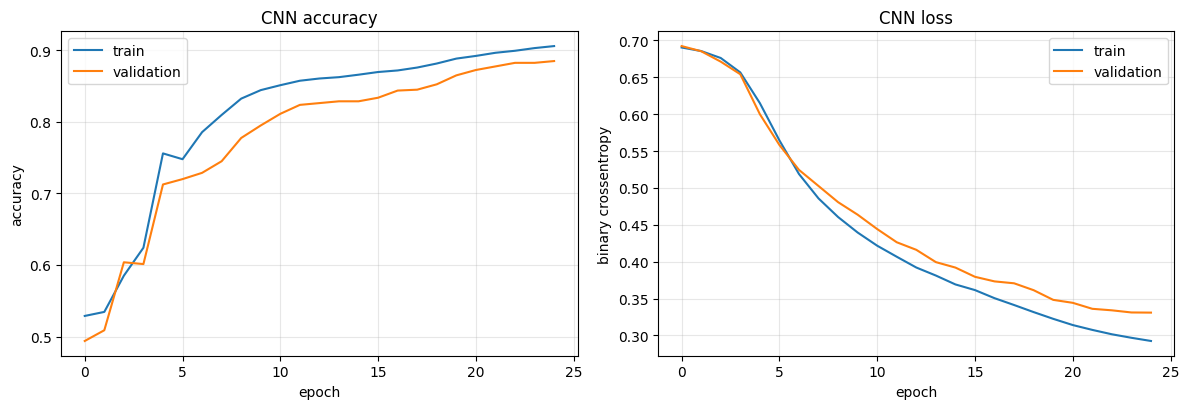

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('CNN accuracy'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('CNN loss'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('binary crossentropy')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
cnn_pred = (cnn.predict(X_test, verbose=0).ravel() >= 0.5).astype(int)
cm = confusion_matrix(y_test, cnn_pred)
print("CNN confusion matrix (rows = actual, cols = predicted)")
print(f"{'':<12}{'clean':>10}{'defective':>12}")
for name, row in zip(["clean", "defective"], cm):
    print(f"{name:<12}{row[0]:>10}{row[1]:>12}")

print("\nRecall by defect type (of the defects the CNN was shown):")
for dtype in DEFECT_TYPES:
    idx = np.where((k_test == dtype) & (y_test == 1))[0]
    if len(idx):
        print(f"  {dtype:<14}{100*cnn_pred[idx].mean():5.1f}%   ({len(idx)} samples)")

CNN confusion matrix (rows = actual, cols = predicted)
                 clean   defective
clean              491          13
defective           93         403

Recall by defect type (of the defects the CNN was shown):
  slub           98.2%   (109 samples)
  hole          100.0%   (140 samples)
  thread_break   32.2%   (115 samples)
  misweave      100.0%   (119 samples)


#### Observation
This is the part that matters more than the headline number, same as Practical 4's per-class recall.

```
slub           98.2%   (109 samples)
hole          100.0%   (140 samples)
thread_break   32.2%   (115 samples)
misweave      100.0%   (119 samples)
```

The CNN doesn't detect defects well in general. It detects **three of the four types nearly perfectly and mostly misses the fourth.**

The error budget reconciles exactly, which is how I know that's the whole story:

| | missed |
|---|---|
| thread breaks (78 of 115) | 78 |
| slubs (2 of 109) | 2 |
| holes, misweaves | 0 |
| noise-flipped labels with no actual defect | 13 |
| **total** | **93**: matches the confusion matrix |

So **84% of every mistake the model makes is a missed thread break.**

My reading of why: slub, hole and misweave all *add* something to the image, a bright bar, a dark blob, a patch where the weave pattern jumps. A thread break *removes* something. It's a strip where the regular weave texture is simply absent, at roughly the same brightness as its surroundings. Detecting "the expected periodic texture is missing here" is a harder ask than detecting "there is a dark spot here", especially for a first conv layer of 16 3x3 filters, 3x3 barely spans one weave period, so a filter that small struggles to represent "the rhythm stopped".

Practically, on a real inspection line this is the number that would decide whether the model ships. 89% overall sounds deployable; "misses two-thirds of thread breaks" probably isn't, and you'd only ever find that out by breaking the results down by defect type.

## The experiment that isolates *why*

The MLP failing and the CNN working is suggestive, not proof. There are two competing explanations:

- **(a)** the MLP can't detect these local patterns at all, or
- **(b)** the MLP can detect them fine, but can't cope with them **moving around**.

These predict different things, so I can separate them. I rebuild the dataset with the defect **pinned to the exact centre** of every image, same defect types, same sizes, same subtlety, only the position variability removed. If (a) is right, the MLP still fails. If (b) is right, the MLP suddenly works.

In [ ]:
rng_fix = np.random.default_rng(42)
Xf_tr, yf_tr, _ = make_set(4000, rng_fix, defect_region=(15,17,15,17))
Xf_te, yf_te, _ = make_set(1000, rng_fix, defect_region=(15,17,15,17))

rng_rnd = np.random.default_rng(42)
Xr_tr, yr_tr, _ = make_set(4000, rng_rnd)
Xr_te, yr_te, _ = make_set(1000, rng_rnd)

print(f"{'':<26}{'MLP':>10}{'CNN':>10}")
print("-" * 46)
for label, (Xa, ya, Xb, yb) in [
        ("defect FIXED at centre", (Xf_tr, yf_tr, Xf_te, yf_te)),
        ("defect at RANDOM spot",  (Xr_tr, yr_tr, Xr_te, yr_te))]:
    row = []
    for builder in (build_mlp, build_cnn):
        m = builder()
        m.fit(Xa, ya, epochs=25, batch_size=64, verbose=0)
        row.append(m.evaluate(Xb, yb, verbose=0)[1])
    print(f"{label:<26}{row[0]:>10.4f}{row[1]:>10.4f}")

                                 MLP       CNN
----------------------------------------------


defect FIXED at centre        0.8450    0.9200


defect at RANDOM spot         0.5040    0.9240


#### Observation
```
                              MLP       CNN
defect FIXED at centre     0.8450    0.9200
defect at RANDOM spot      0.5040    0.9240
```

That settles it, and cleanly.

Pin the defect to the centre and **the MLP jumps from chance to 84.5%.** So explanation (a) is dead. The MLP can detect these defects perfectly well. The patterns are not too subtle, the images are not too noisy, the network is not too small.

Let the defect move and the MLP falls 34 points, straight back to chance. The CNN doesn't move at all: 92.0% → 92.4%.

So the MLP's entire failure was **position**, nothing else. This is exactly the limitation described at the top of the notebook, now measured instead of asserted: a Dense layer learns "dark blob at pixel (5,5) means defect" as a fact about pixel (5,5). Move the blob to (20,20) and that knowledge is worth nothing, because a different set of weights lives there, weights that would have to learn the same lesson again, independently, for all 1024 positions, from a training set that only shows each position a handful of times.

The convolution shares one filter across every position, so it learns the lesson once and it applies everywhere. That is the entire reason CNNs exist for images, and this table is the proof of it.

## Does the CNN really generalise across position?

The test above shows the CNN tolerates moving defects. The stronger claim is that a filter learned in one place works in places the network **never saw a defect at all**. So: train with every defect confined to the left half of the frame, then test on the right half.

For a Dense layer this is impossible by construction, the right-half weights would receive no defect signal during training. For a convolution it should be nearly free, because it's the same filter either way.

In [ ]:
rng_pos = np.random.default_rng(7)
Xl_tr, yl_tr, _ = make_set(4000, rng_pos, defect_region=(6,15,6,26))   # LEFT half only
Xl_te, yl_te, _ = make_set(600,  rng_pos, defect_region=(6,15,6,26))   # left  (seen)
Xr_te2, yr_te2, _ = make_set(600, rng_pos, defect_region=(18,26,6,26)) # right (NEVER seen)

print(f"{'':<8}{'left half (seen)':>20}{'right half (unseen)':>22}{'drop':>9}")
print("-" * 59)
for name, builder in [("MLP", build_mlp), ("CNN", build_cnn)]:
    m = builder()
    m.fit(Xl_tr, yl_tr, epochs=25, batch_size=64, verbose=0)
    seen   = m.evaluate(Xl_te,  yl_te,  verbose=0)[1]
    unseen = m.evaluate(Xr_te2, yr_te2, verbose=0)[1]
    print(f"{name:<8}{seen:>20.4f}{unseen:>22.4f}{seen-unseen:>9.4f}")

            left half (seen)   right half (unseen)     drop
-----------------------------------------------------------


MLP                   0.5033                0.4933   0.0100


CNN                   0.9383                0.9250   0.0133


#### Observation
```
        left half (seen)   right half (unseen)     drop
CNN               0.9383                0.9250   0.0133
MLP               0.5033                0.4933   0.0100
```

The CNN was trained on defects that **only ever appeared in the left half** of the frame. Tested on the right half (a region where it never saw a single defect during training) it scores 92.5%, losing 1.3 points.

It didn't learn "defects live on the left". It learned what a defect looks like, and that knowledge transferred to territory it had no examples from, because it's the same filter sliding over both halves. Parameter sharing isn't just a memory saving. It's the network generalising across position for free.

**One honest caveat about that MLP row:** its "drop" of 0.010 looks comparable to the CNN's 0.013, which would be a completely wrong reading. The MLP scored 50.3% on the half it *was* trained on. It never learned anything to transfer, so this experiment says nothing about MLP transfer either way. Only the CNN row carries information here.

## What did the filters actually learn?

The first convolution layer holds 16 filters of 3x3. Running an image through and looking at the feature maps shows where each filter fired.

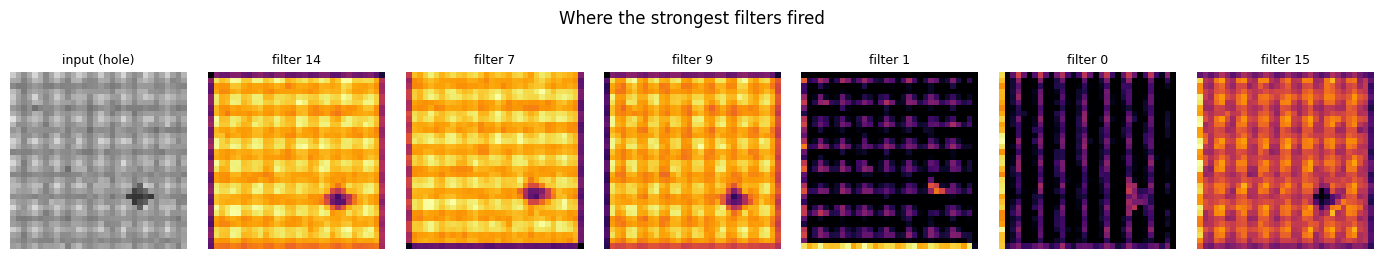

In [ ]:
feature_model = tf.keras.Model(cnn.inputs, cnn.layers[0].output)

defect_idx = np.where((y_test == 1) & (k_test == "hole"))[0][0]
sample = X_test[defect_idx:defect_idx+1]
maps = feature_model.predict(sample, verbose=0)[0]

fig, axes = plt.subplots(1, 7, figsize=(14, 2.4))
axes[0].imshow(sample[0,:,:,0], cmap='gray', vmin=0, vmax=1)
axes[0].set_title("input (hole)", fontsize=9); axes[0].axis('off')
strongest = np.argsort(maps.max(axis=(0,1)))[::-1][:6]
for ax, f in zip(axes[1:], strongest):
    ax.imshow(maps[:,:,f], cmap='inferno')
    ax.set_title(f"filter {f}", fontsize=9); ax.axis('off')
plt.suptitle("Where the strongest filters fired", y=1.06)
plt.tight_layout(); plt.show()

#### Observation
Each panel is the output of one 3x3 filter applied across the whole image, the six that responded most strongly, on an image containing a hole.

The thing to notice is what kind of object a feature map is: it's still a **grid**, not a flat list. It preserves *where* each response happened, which is what lets the next convolution layer build on it spatially and what makes the eventual pooling meaningful. The moment you flatten to a Dense layer you throw that structure away, which is precisely the MLP's problem measured two sections above.

Different filters respond to different local patterns; the bright regions are where a given filter found what it's tuned for. Nothing here was designed by hand, the 3x3 weights are just what backpropagation settled on as useful for separating clean from defective.

## Sanity check on real photographs

The fabric set is generated, which is what let me control position and brightness precisely enough to run those experiments. Fair challenge in return: does any of this hold on real measured images?

Fashion-MNIST (real photographed garments) reduced to the two hardest classes to tell apart, **pullover vs shirt**. Both are dark torso-shaped blobs; the difference is in local detail like buttons, collars and sleeve edges.

real images -> train (12000, 28, 28, 1)  test (2000, 28, 28, 1)


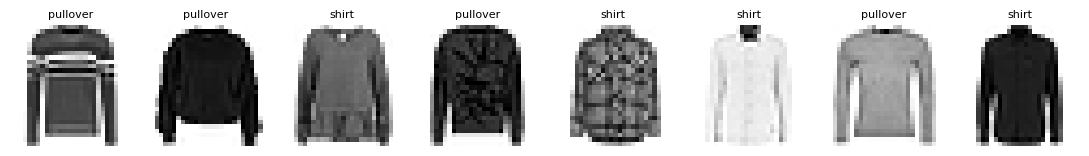

In [ ]:
import gzip, urllib.request, os

BASE = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
os.makedirs("fashion", exist_ok=True)
def grab(fname):
    path = os.path.join("fashion", fname)
    if not os.path.exists(path):
        urllib.request.urlretrieve(BASE + fname, path)
    return path

def load(img_file, lab_file):
    with gzip.open(grab(img_file), 'rb') as f:
        X = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)
    with gzip.open(grab(lab_file), 'rb') as f:
        y = np.frombuffer(f.read(), np.uint8, offset=8)
    return X, y

Xf_all, yf_all = load('train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz')
Xf_ts,  yf_ts  = load('t10k-images-idx3-ubyte.gz',  't10k-labels-idx1-ubyte.gz')

def two_class(X, y, a=2, b=6):        # 2 = pullover, 6 = shirt
    m = (y == a) | (y == b)
    return (X[m]/255.0).astype('float32')[..., None], (y[m] == b).astype(int)

Xg_tr, yg_tr = two_class(Xf_all, yf_all)
Xg_te, yg_te = two_class(Xf_ts,  yf_ts)
print("real images -> train", Xg_tr.shape, " test", Xg_te.shape)

fig, axes = plt.subplots(1, 8, figsize=(11, 1.7))
for ax, i in zip(axes, range(8)):
    ax.imshow(Xg_tr[i,:,:,0], cmap='gray_r')
    ax.set_title("shirt" if yg_tr[i] else "pullover", fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
for name, builder in [("MLP", build_mlp), ("CNN", build_cnn)]:
    m = builder(input_shape=(28,28,1))
    m.fit(Xg_tr, yg_tr, epochs=12, batch_size=64, verbose=0)
    acc = m.evaluate(Xg_te, yg_te, verbose=0)[1]
    print(f"{name}: test accuracy {acc:.4f}   parameters {m.count_params():,}")

MLP: test accuracy 0.8950   parameters 108,801


CNN: test accuracy 0.8955   parameters 5,889


#### Observation
```
MLP: test accuracy 0.8950   parameters 108,801
CNN: test accuracy 0.8955   parameters   5,889
```

**A dead tie.** 89.50% versus 89.55% is noise, not a difference. And on the fabric set the same two models were 39 points apart.

I nearly wrote this up as a disappointing result before thinking about *why*, and the why turns out to confirm the whole thesis rather than dent it.

Fashion-MNIST garments are **centred and size-normalised**. Every pullover sits in the middle of the frame at roughly the same scale, every shirt likewise. The collar is always in the top third; the sleeve edges are always at the sides. There is essentially **no position variability**: which is exactly the condition under which a convolution's advantage disappears, because there's nothing to be invariant to. A Dense layer's "learn each position separately" strategy is fine when the object is always in the same position.

So the two results agree with each other perfectly:

- Fabric, defect anywhere → CNN wins by 39 points
- Fashion-MNIST, object always centred → CNN wins by nothing

The CNN's edge is specifically translation invariance, and here's a real dataset where it doesn't apply. What the CNN still gets is the same accuracy for **18x fewer parameters**, which on a production line means a smaller, faster model.

The lesson I'd actually take from this: a CNN isn't automatically better because it's a CNN. It's better when the thing you're looking for can appear anywhere. Somebody benchmarking only on pre-centred datasets could reasonably conclude convolutions don't matter much, and be badly wrong about their own problem.

### Personal notes

**The experiment is the practical, not the model.** Getting a CNN to 89% took one afternoon and about fifteen lines. What actually taught me something was refusing to accept "the CNN is better because convolutions are good at images" and building the fixed-centre test to force the question. The MLP going 50.4% → 84.5% purely from pinning the defect in place is the single most useful number in this notebook, because it converts a slogan I'd read in every textbook into something I measured myself. Before that test I couldn't have told you whether the MLP was failing because the defects were too subtle or because they moved. Those look identical from the accuracy alone.

**I designed the dataset so the cheap solution wouldn't work.** Making defects brightness-neutral was deliberate, if a slub only ever brightened the image, thresholding the mean would score well and the CNN's win would prove nothing about convolution. The verified means (0.6437 clean, 0.6445 defective) confirm that hole got closed. The statistics baseline still found 68.6% through the minimum-pixel leak on holes, which I'd rather report than hide; it's a reminder that a model beating chance isn't impressive until you know what a dumb rule scores.

**The thread break result is the honest blemish.** 89% overall reads like a working inspection system. Broken down, it's three defect types at 98-100% and thread breaks at 32.2%. And 84% of all errors are that one type. I could have quietly reported the aggregate. But a QC model that misses two-thirds of one defect category is not deployable, and that fact is invisible in the headline number. Same lesson as Practical 4's Fan class: the aggregate hides which part of the problem the architecture actually solved.

**The Fashion-MNIST tie is my favourite result in the notebook.** Two models 39 points apart on fabric finish dead level on real photos, because Fashion-MNIST is centred, so there's no position variability for the convolution to exploit. It'd be easy to spin that as a failed experiment. It's the opposite: it's a control condition that isolates *why* the CNN won earlier. If the CNN had also won here, I couldn't have claimed the advantage was translation invariance specifically.

**What I'd fix given more time:** the thread break case wants a larger first-layer filter, 3x3 barely spans one weave period, so it can't easily represent "the periodic texture stops here". 5x5 or 7x7 filters in the first block would be the thing to try, and I'd want to check it rather than assume it, since I've been wrong about this kind of prediction before in these labs.

#### Summary
- A `Dense` layer gives every pixel a private weight, so what it learns at one position is worthless at another. A `Conv2D` layer slides one small filter everywhere, learning a pattern once and applying it at every location, **parameter sharing**.
- On fabric defect detection with defects appearing anywhere: statistics baseline 68.6%, MLP **50.4%** (chance, at 139,521 parameters), CNN **89.4%** at 5,889 parameters, 24x fewer weights, 39 points better.
- The MLP's failure was not tuning. Four configurations up to 1,050,625 parameters and two learning rates all sat at chance.
- **The isolating experiment:** pin every defect to the image centre and the MLP jumps 50.4% → 84.5%, while the CNN is unchanged (92.0% → 92.4%). So the MLP could always detect these defects; it could never cope with them *moving*. Position was the entire problem.
- **Generalisation across position:** train the CNN with defects only in the left half, test on the right half where it saw none, 93.8% → 92.5%, a 1.3 point drop. The filter transfers to unseen territory for free.
- Per defect type, the CNN is not uniformly good: slub 98.2%, hole 100%, misweave 100%, **thread break 32.2%**. 84% of all errors are missed thread breaks, the one defect defined by texture being *absent* rather than something being added.
- On real photographs (Fashion-MNIST, pullover vs shirt) the MLP and CNN **tie** at 89.5%. Those garments are pre-centred, so there's no position variability and the convolution's advantage vanishes, which confirms the advantage was translation invariance specifically. The CNN matches it with 18x fewer parameters.
- A CNN is better when the thing you're looking for can appear anywhere. When it's always in the same place, a Dense layer does fine.